In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max, distribution_split

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max, fig_bottleneck_median_scale

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

## embedding loading and mask making 

In [ ]:
sex_color = "female_orange"
for i in range(5):
    globals()[f"embd_10x_{sex_color}_{i}"] = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", f"embd_10x_{sex_color}_split_{i}.npy"))

In [ ]:
embd_10x_female_orange_0.shape[0]*5

25000

# make mask

In [ ]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_female", k=k)
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange = [idx in idx_orange for idx in full_d['clusters']]


# fig_bottleneck_median_scale of resample

## scale = 2

Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


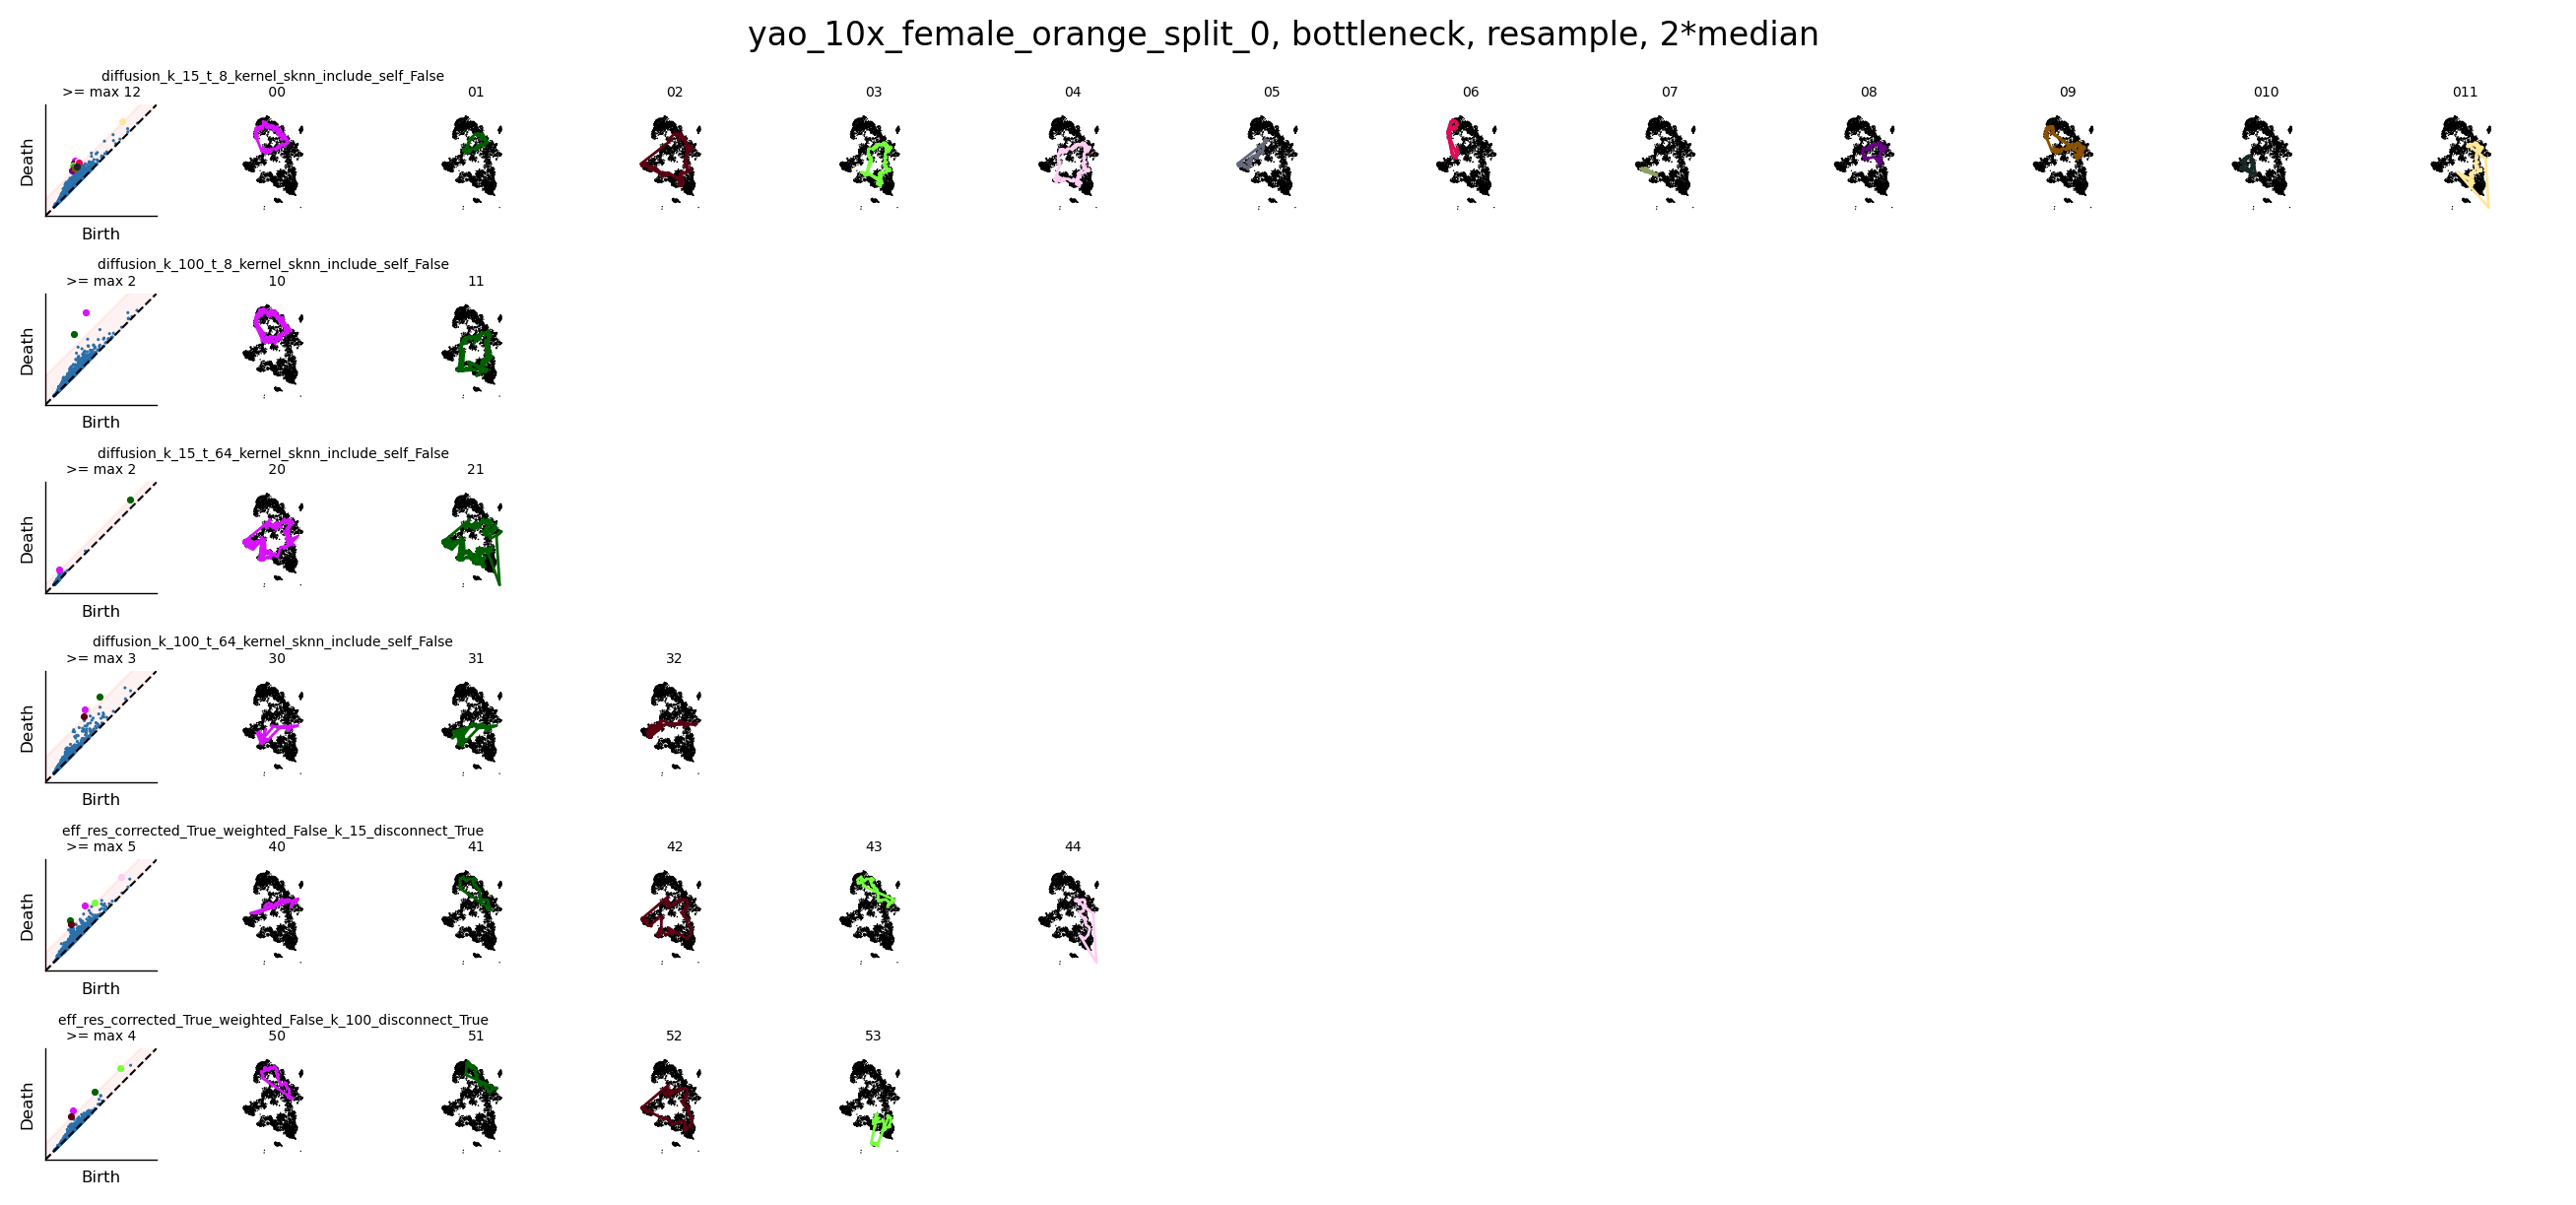

In [ ]:
i = 0
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 2, save = False)
# globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_2.pkl"))

Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


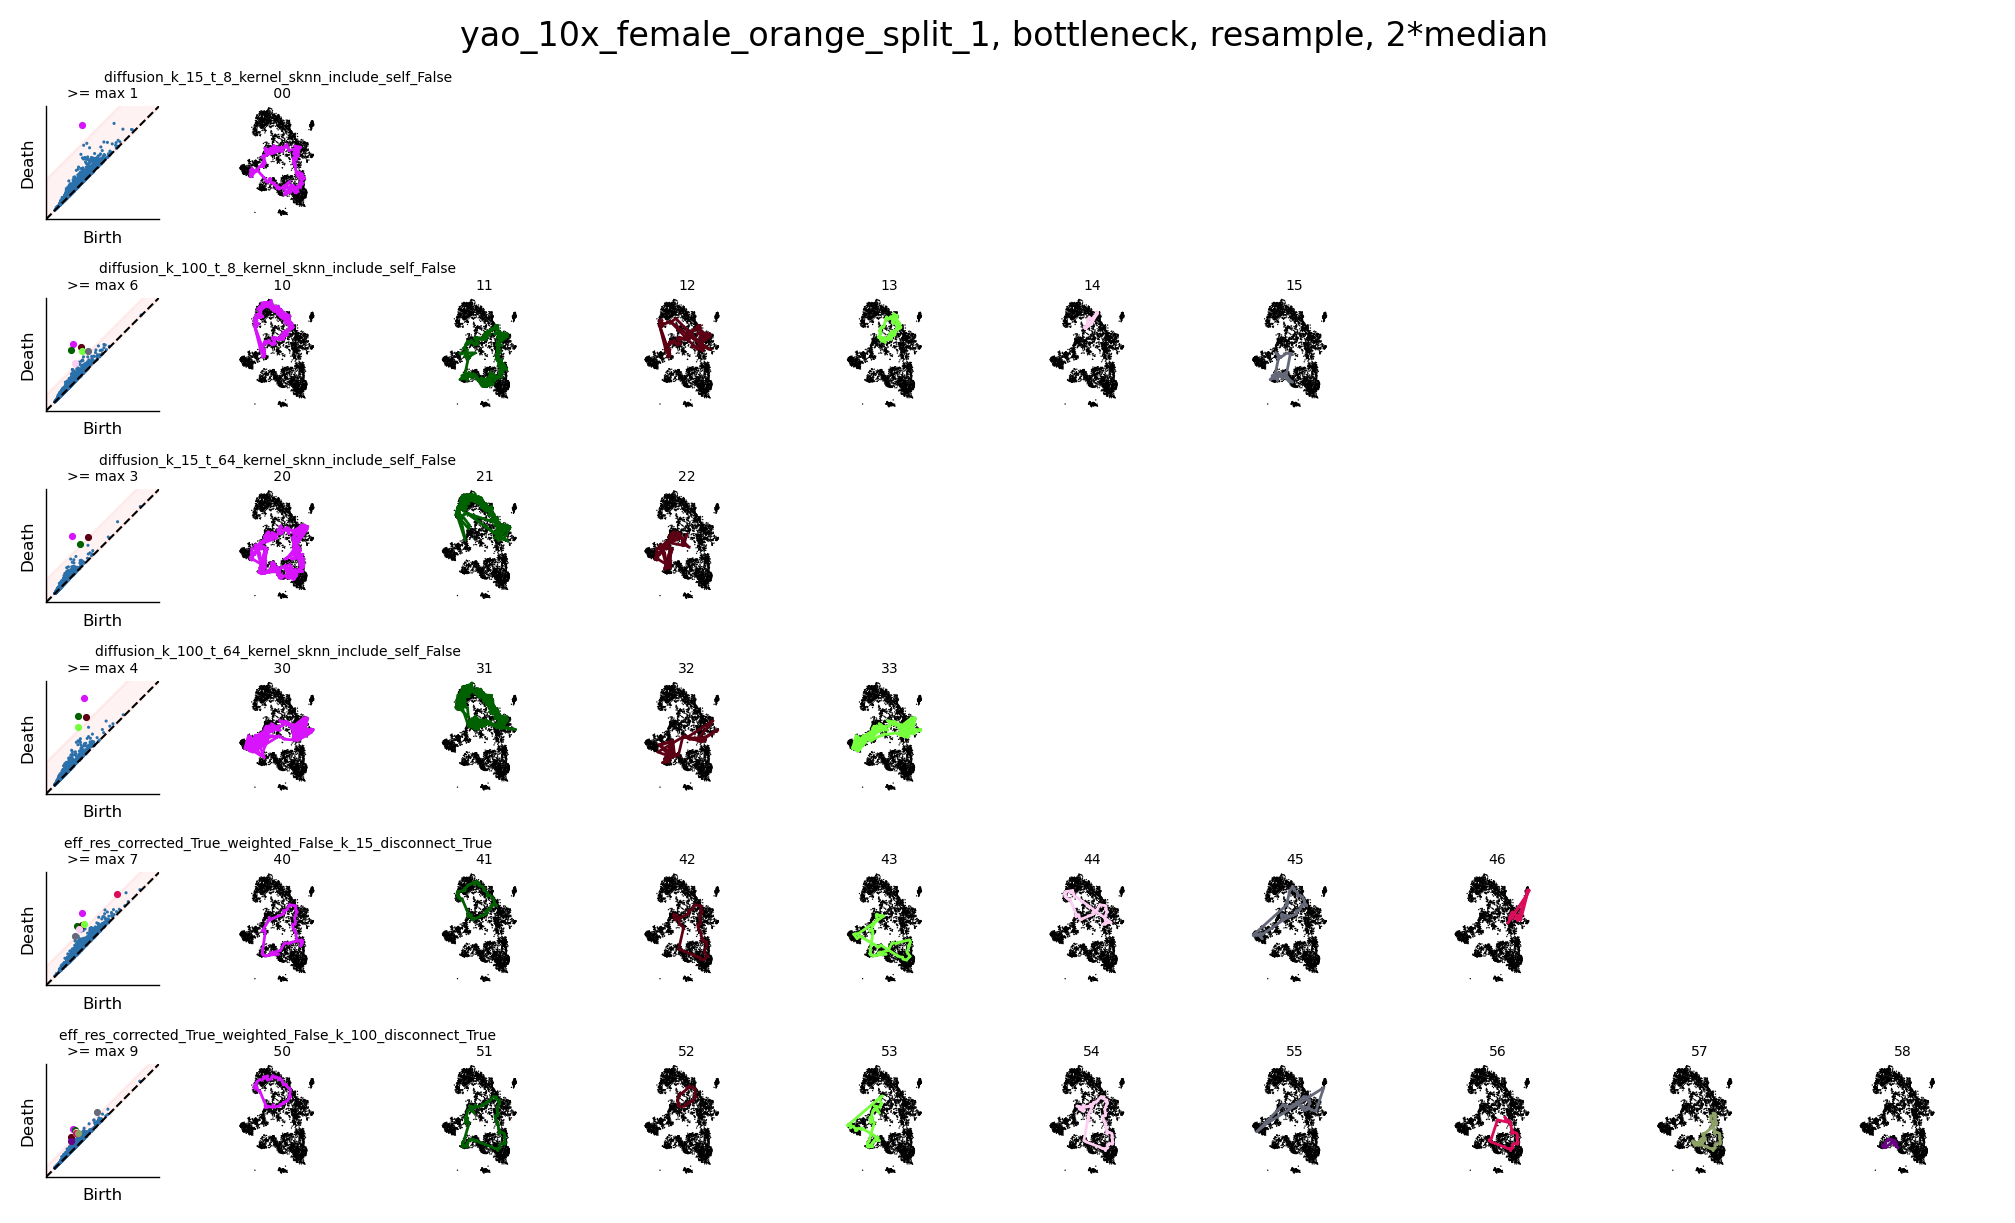

In [ ]:
i = 1
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 2, save = False)
# globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_2.pkl"))

Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


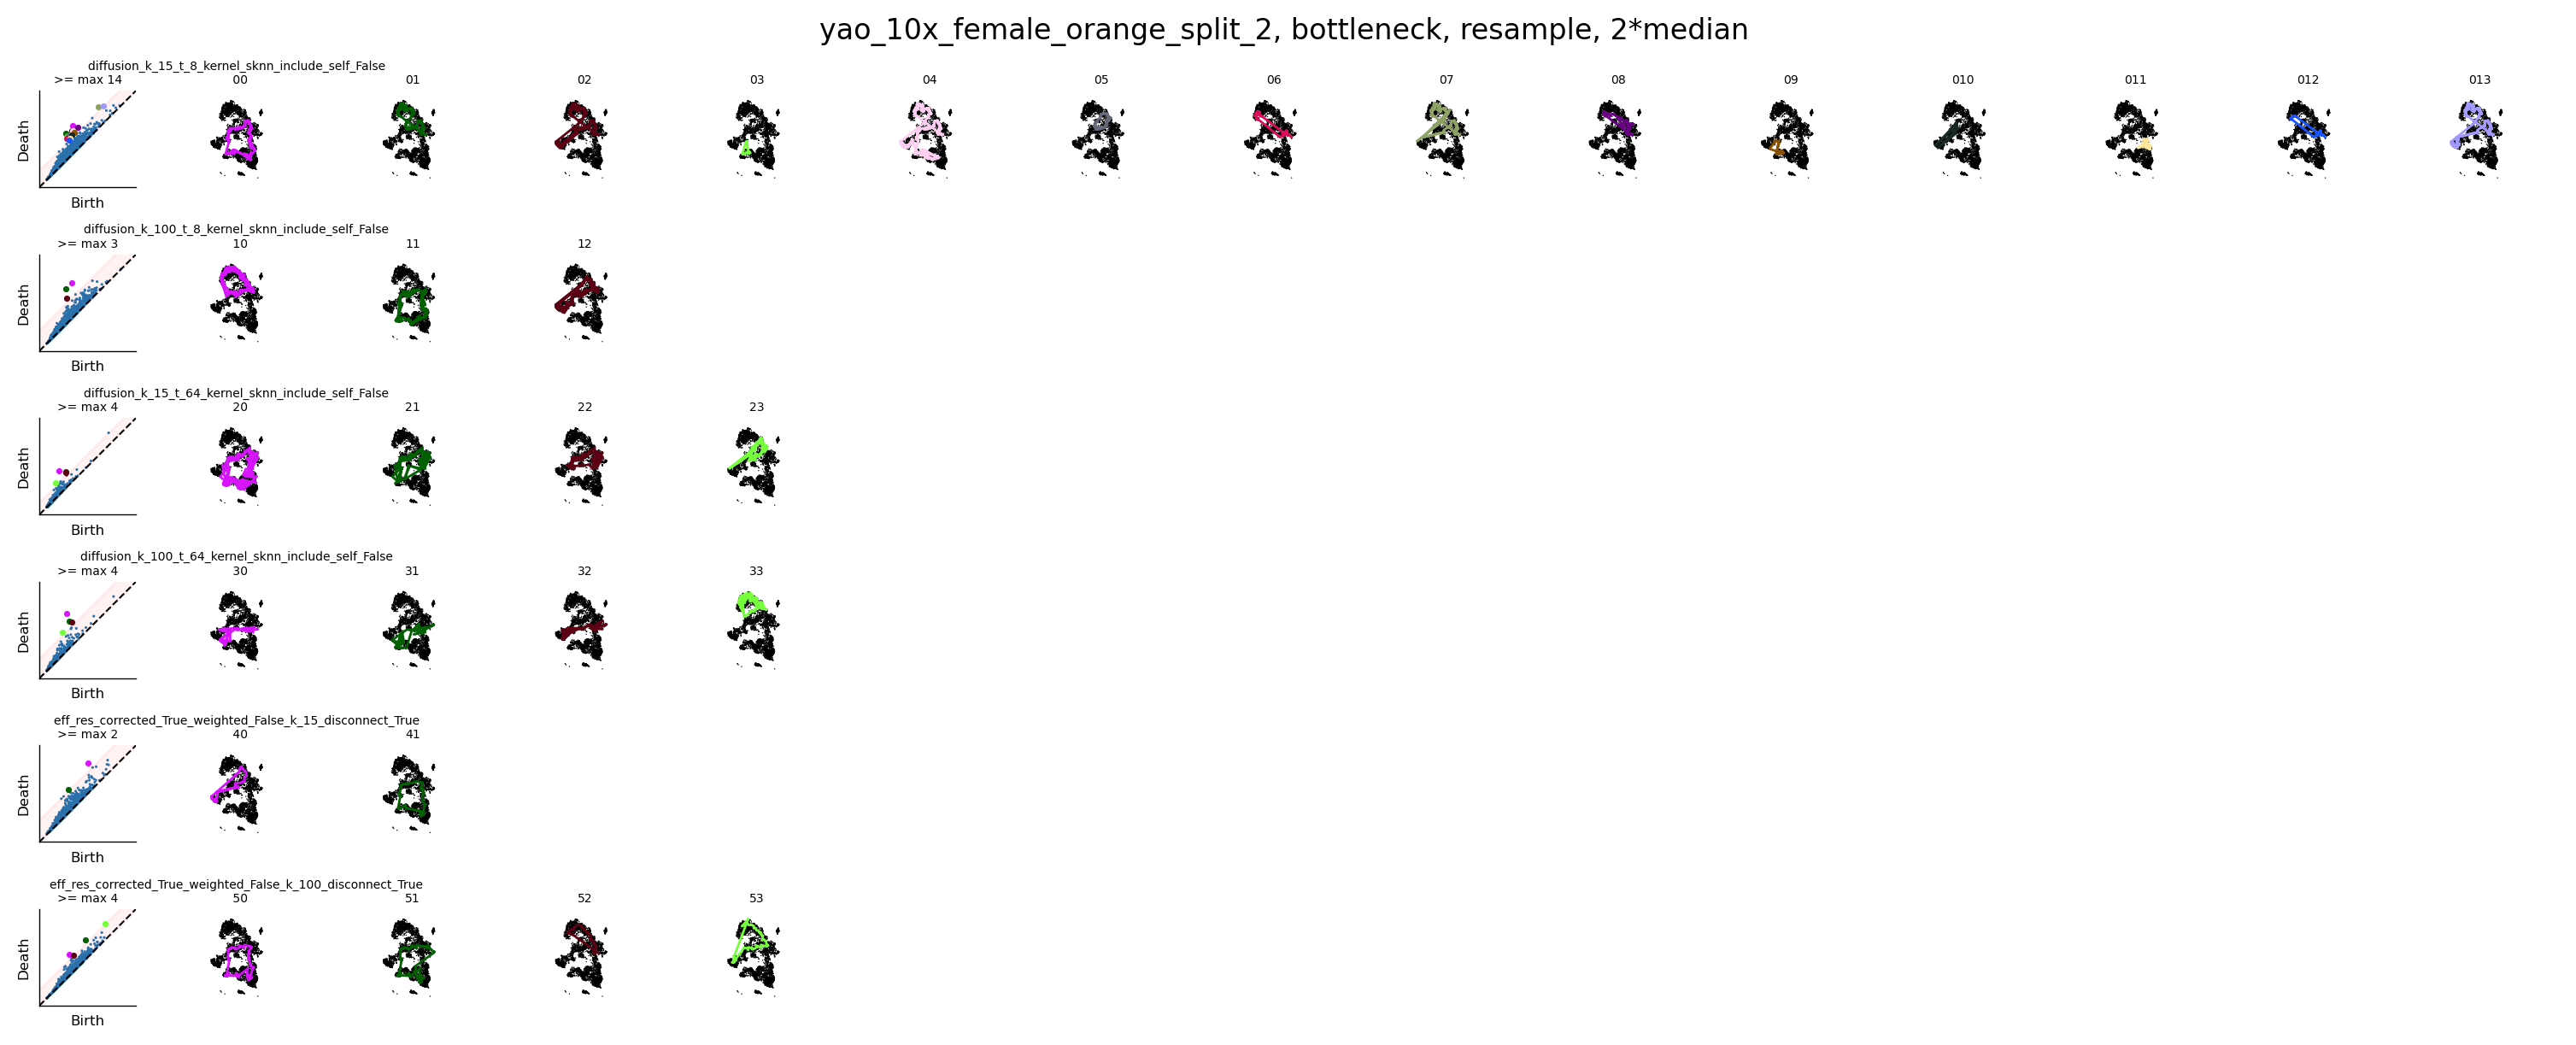

In [ ]:
i = 2
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 2, save = False)
# globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_2.pkl"))

Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


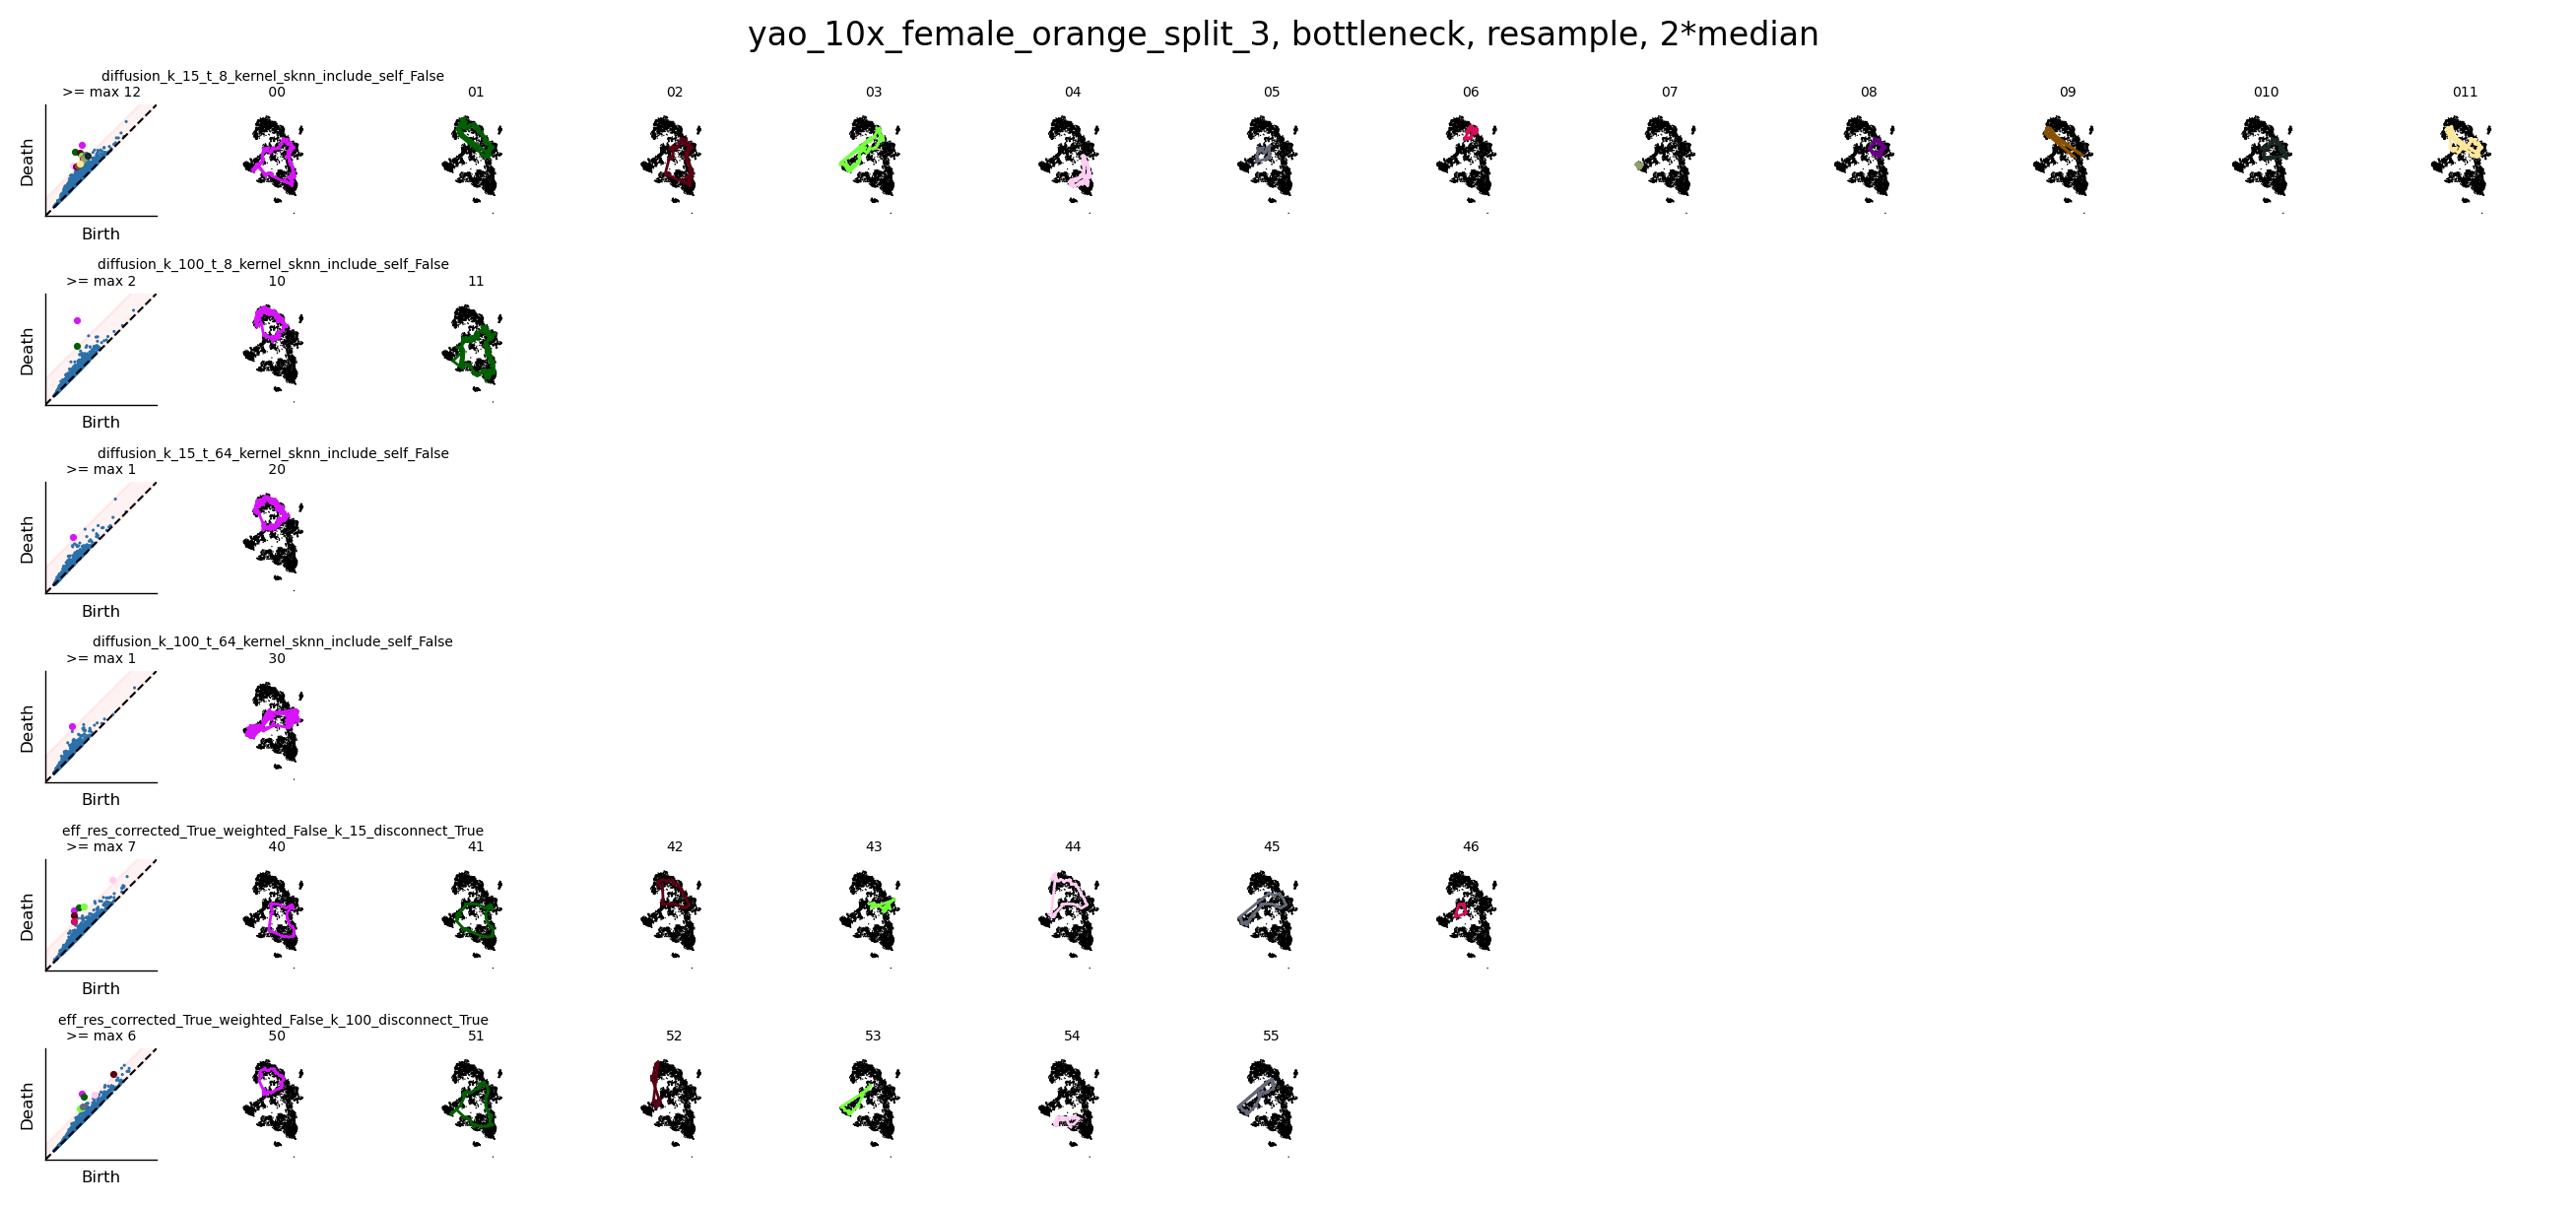

In [ ]:
i = 3
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 2, save = False)
# globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_2.pkl"))

Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


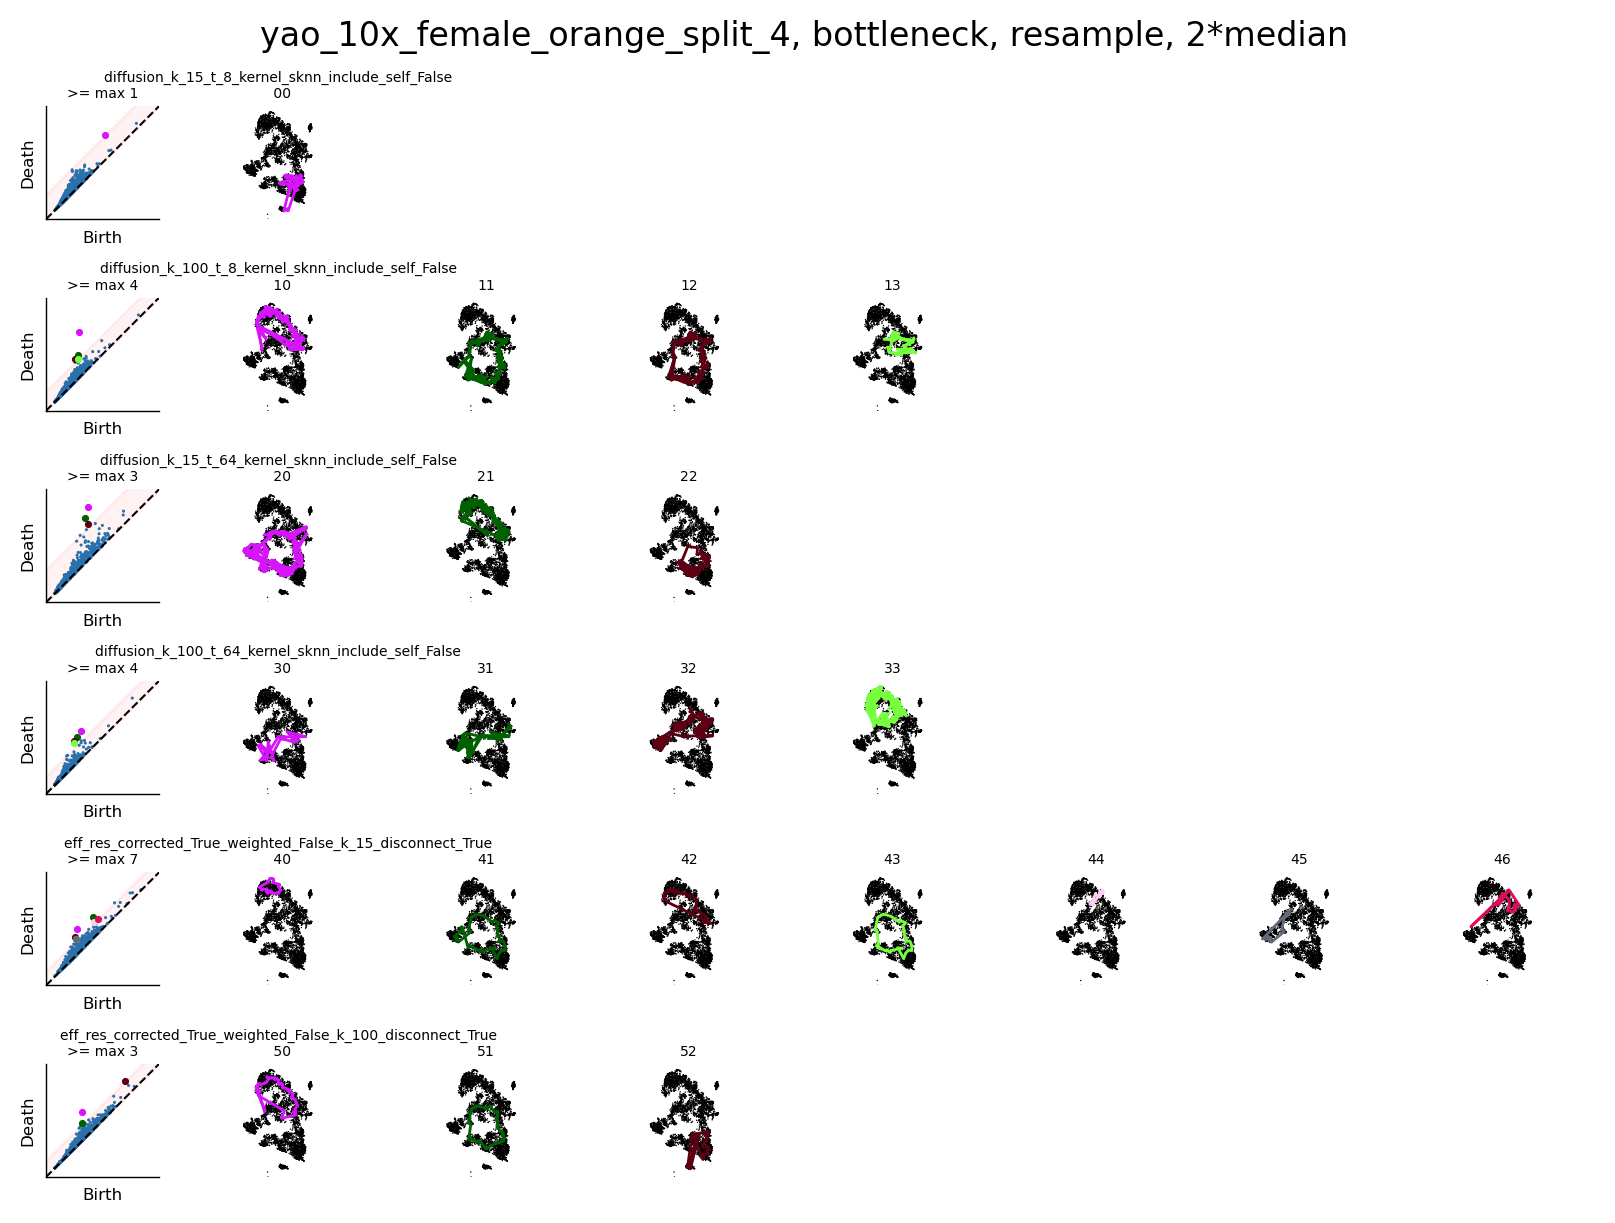

In [ ]:
i = 4
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 2, save = False)
# globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_2.pkl"))

## scale = 3

Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


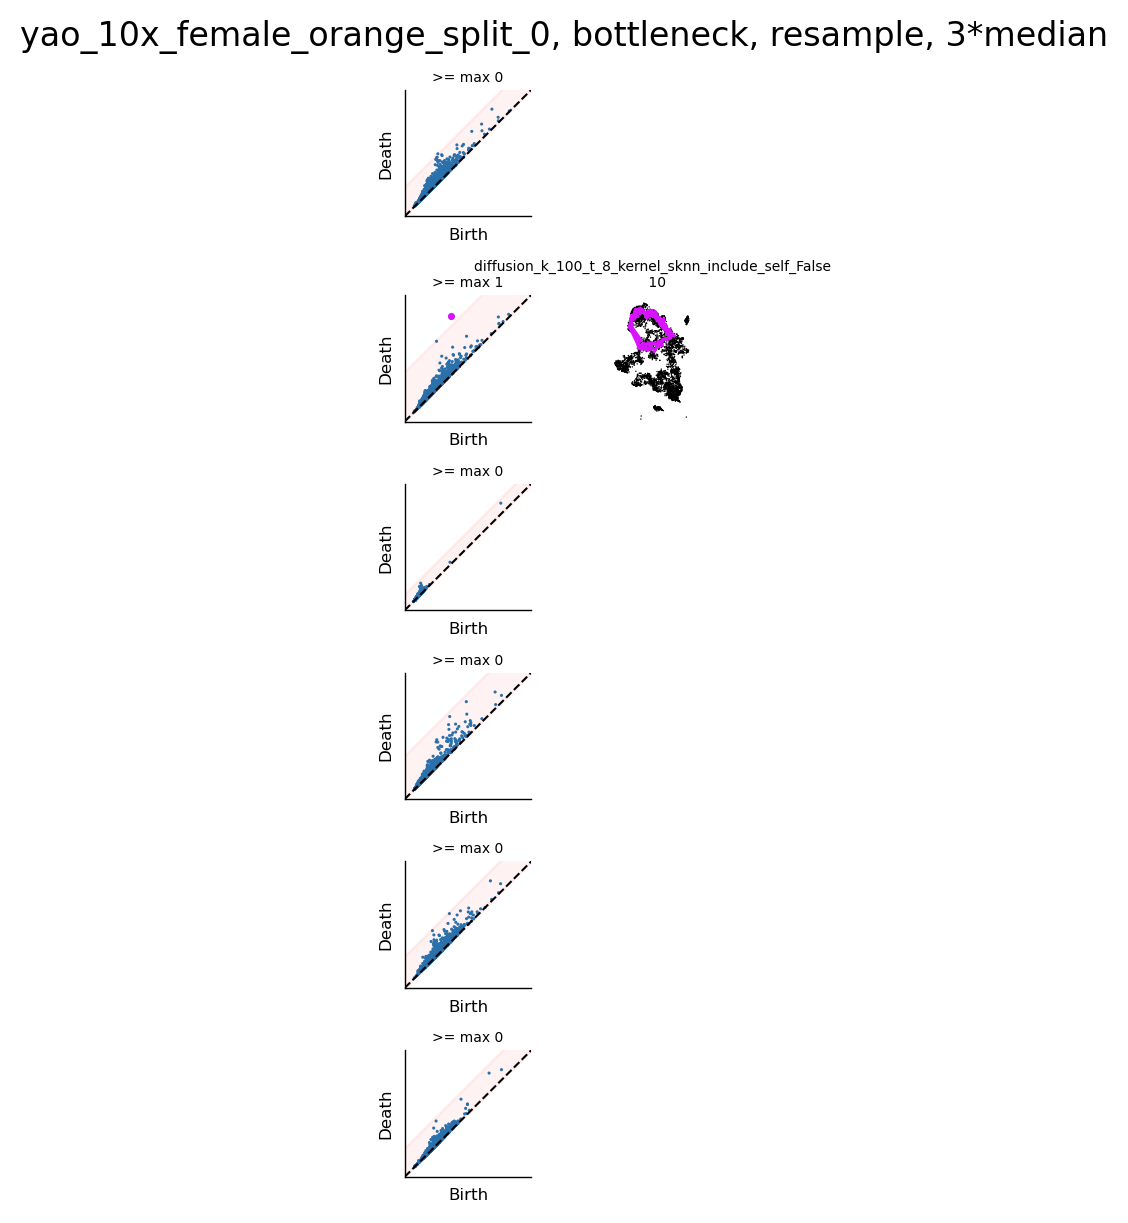

In [ ]:
i = 0
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 3, save = False)
globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_3.pkl"))

Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


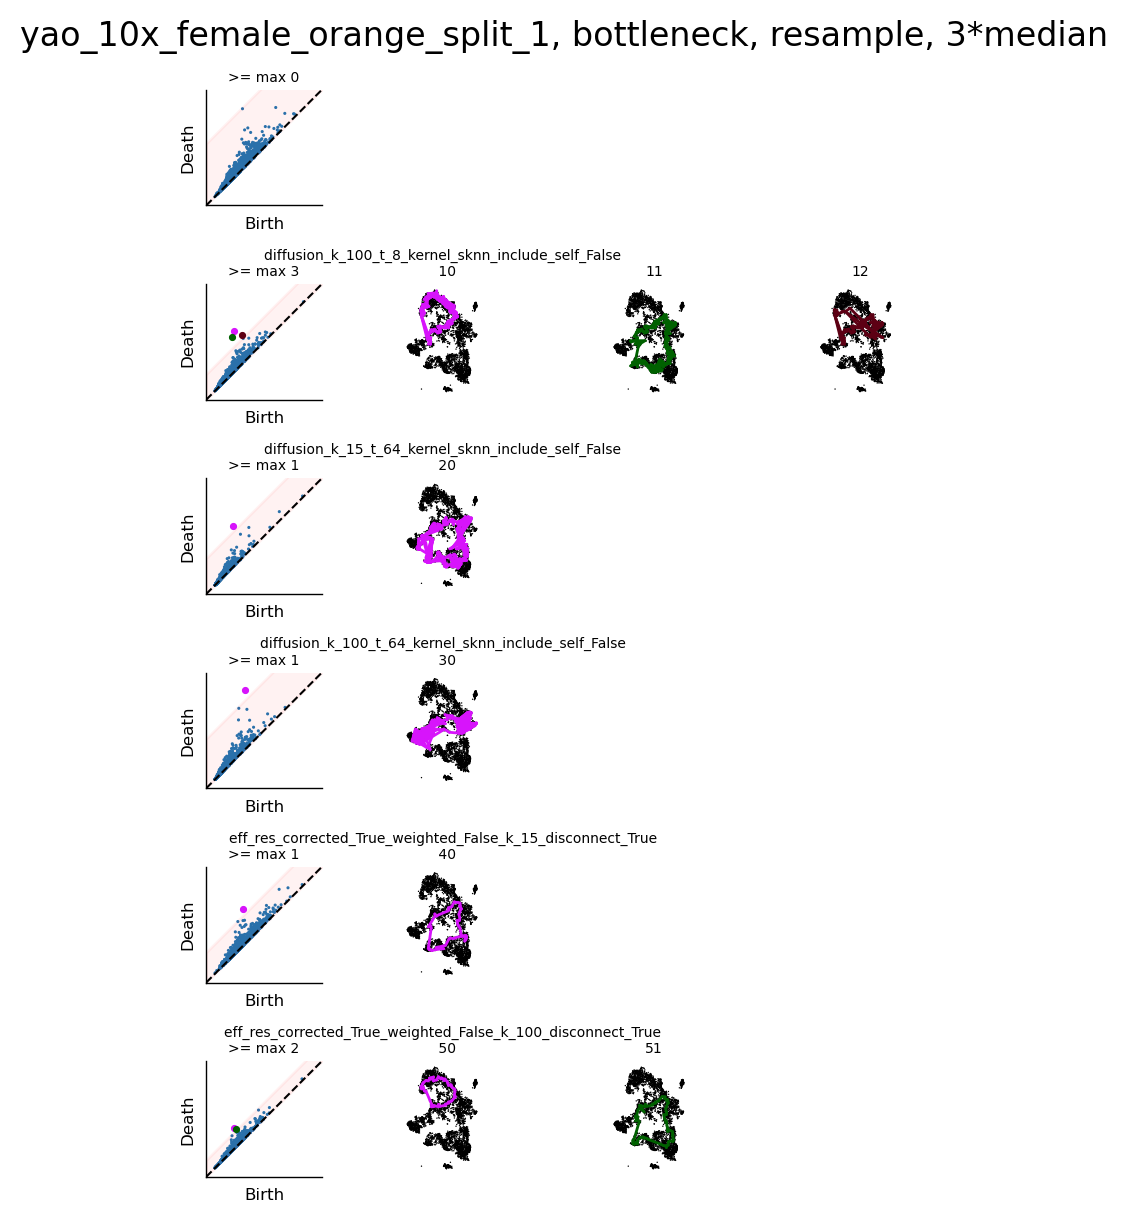

In [ ]:
i = 1
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 3, save = False)
globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_3.pkl"))

Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


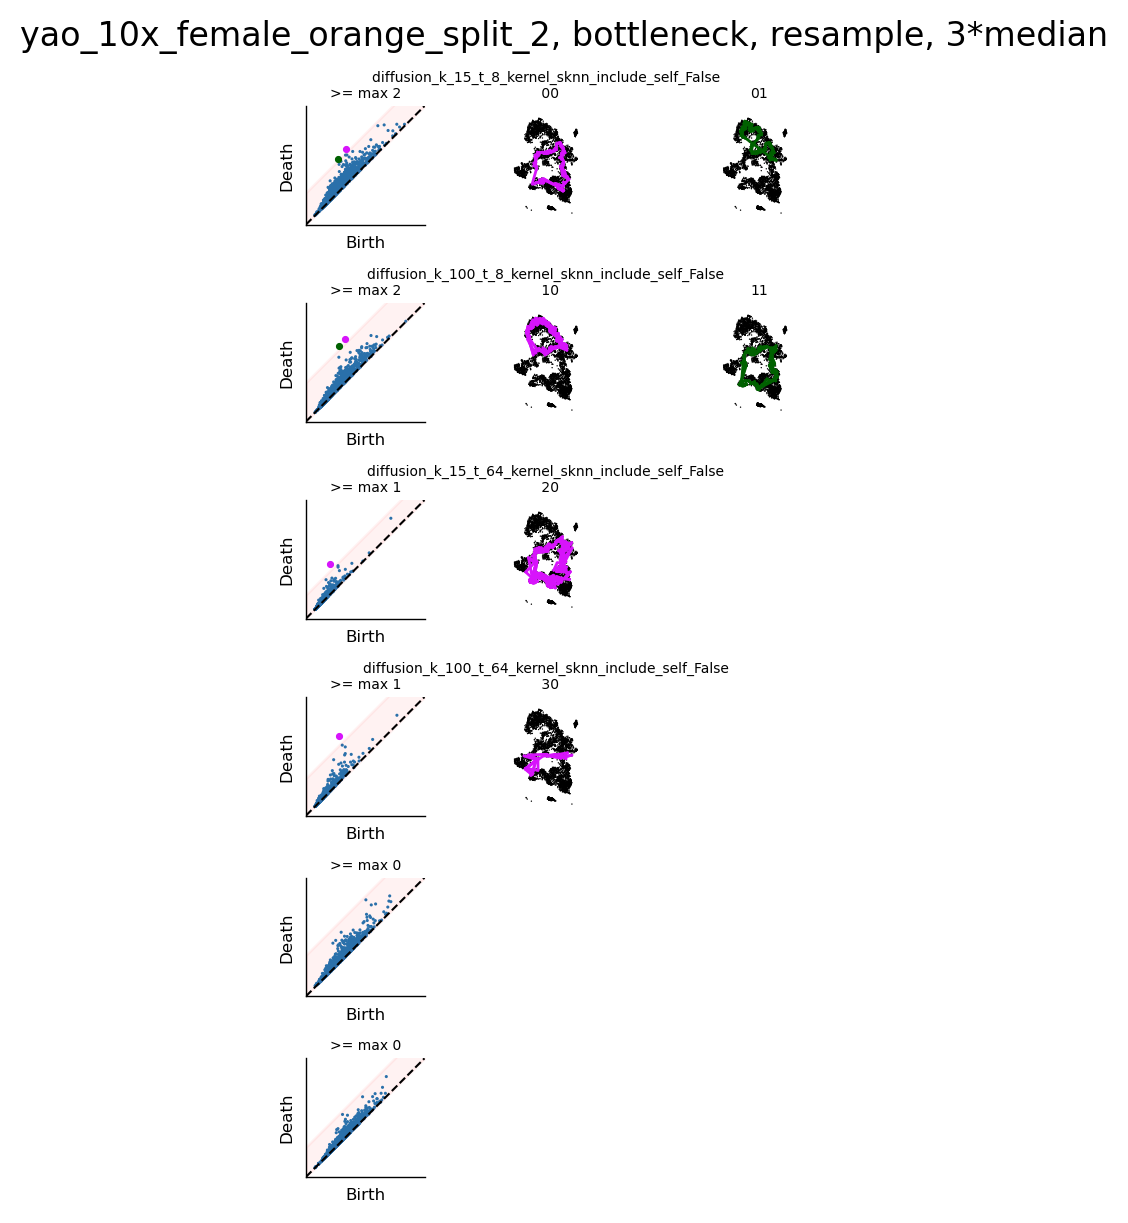

In [ ]:
i = 2
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 3, save = False)
globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_3.pkl"))

Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


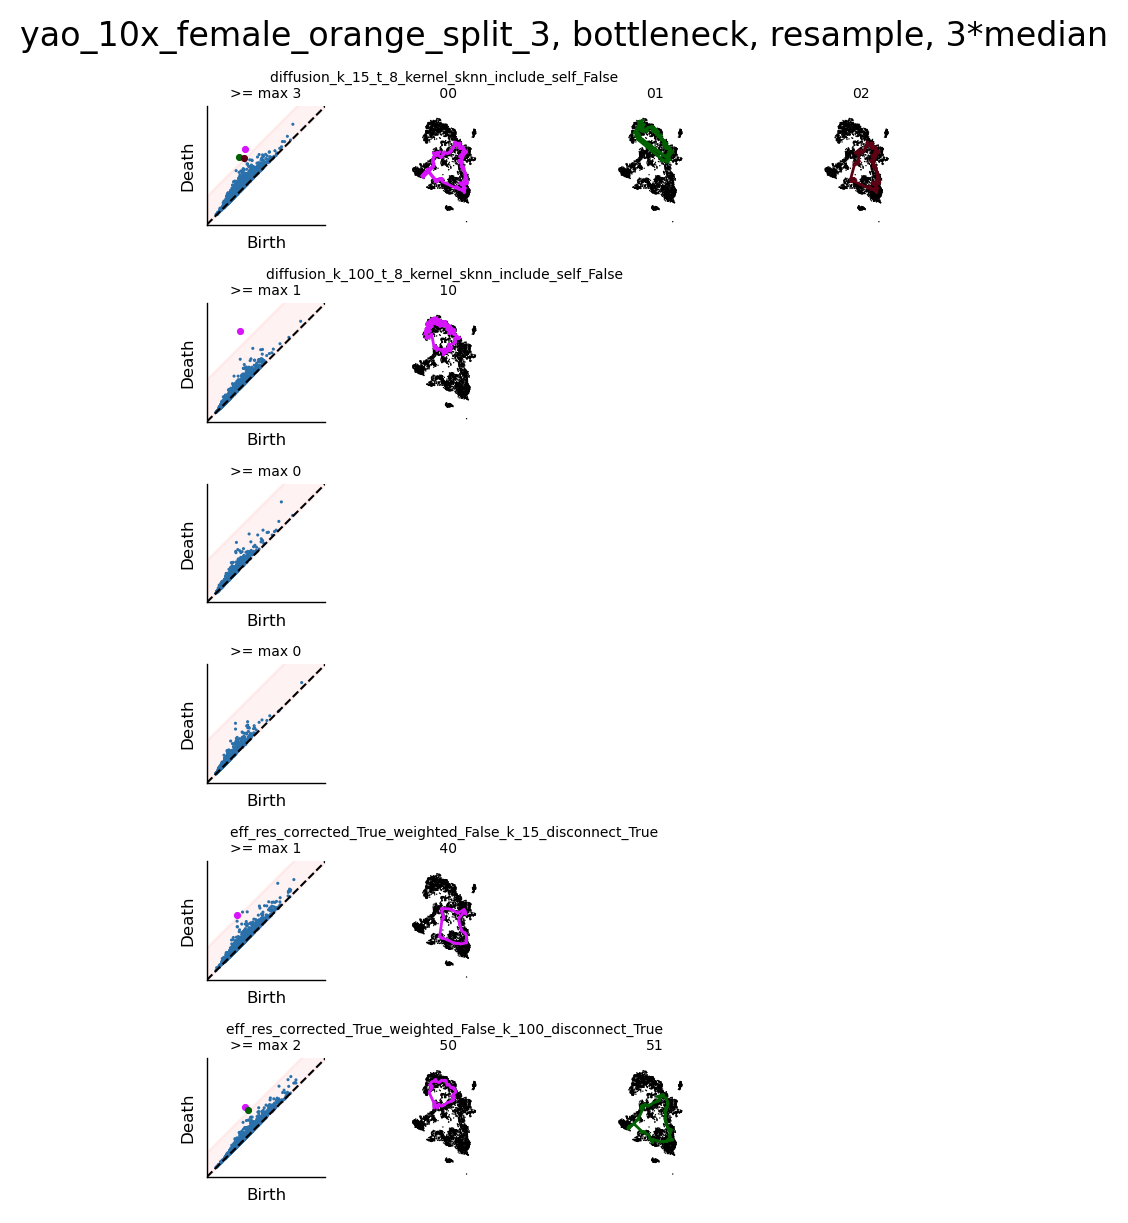

In [ ]:
i = 3
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 3, save = False)
globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_3.pkl"))

Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


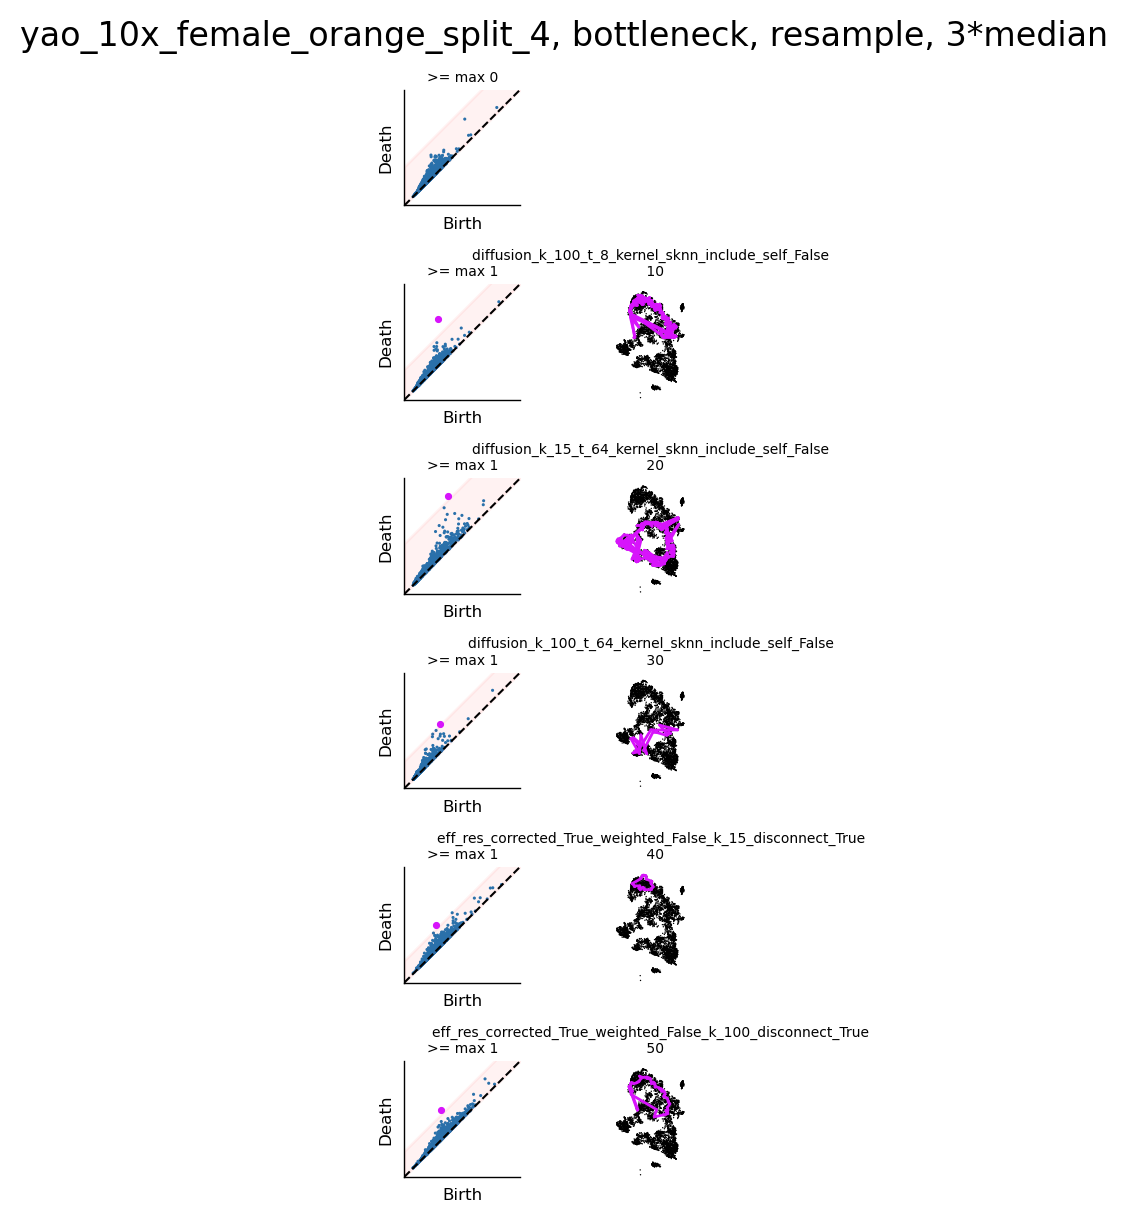

In [ ]:
i = 4
dataset = f"yao_10x_female_orange_split_{i}"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  globals()[f"embd_10x_female_orange_{i}"], method="resample", scale = 3, save = False)
globals()[f"dist{i}"] = distribution_split(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(globals()[f"dist{i}"], os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_split_{i}_scale_3.pkl"))

In [ ]:
dist = {}
dist['clusters'] = dist1['clusters']
dist.keys()

dict_keys(['clusters'])

In [ ]:
dist['idx'] = [a for i in range(5) for a in globals()[f"dist{i}"]['idx']]

In [ ]:
dist['density'] = np.array([a for i in range(5) for a in globals()[f"dist{i}"]['density']])

In [ ]:
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_10x_female_orange_splits_scale_3.pkl"))

In [ ]:
dist['density'].shape

(27, 61)